# Temporal QA Generation

Single-stage event-free temporal QA generation.

Supported QA types: `given_when_ask_what`, `given_what_ask_when`, `visible_anatomy`, `next_action_guidance`.

## 1. Setup paths and imports

In [1]:
from pathlib import Path
import sys, json, os

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SCRIPTS_DIR = REPO_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

print("REPO_ROOT  =", REPO_ROOT)
print("SCRIPTS_DIR=", SCRIPTS_DIR)

REPO_ROOT  = /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding
SCRIPTS_DIR= /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/scripts


In [ ]:
from temporal_qa_generation import (
    load_clip_from_clips_json,
    slice_asr_text_for_clip,
    generate_temporal_qa_for_clip,
    SUPPORTED_QA_TYPES,
)
from _video_llm import build_openrouter_client, DEFAULT_MODEL

print("DEFAULT_MODEL =", DEFAULT_MODEL)
print("Supported QA  =", sorted(SUPPORTED_QA_TYPES))

DEFAULT_MODEL = google/gemini-2.5-flash
Supported QA  = ['given_what_ask_when', 'given_when_ask_what', 'next_action_guidance', 'visible_anatomy']


## 2. Pick a clip

Default test clip: `8V649L5Q368`, clip index `1`
(pneumothorax lung ultrasound segment, ~87.45s → 250.17s).

In [ ]:
VIDEO_ID = "8V649L5Q368"
CLIP_IDX = 1

CLIPS_JSON      = REPO_ROOT / "results" / "clips"       / f"{VIDEO_ID}_clips.json"
TRANSCRIPT_JSON = REPO_ROOT / "results" / "transcripts" / f"{VIDEO_ID}.json"

candidate_videos = [
    Path("UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning") / f"{VIDEO_ID}.mp4",
    REPO_ROOT / "UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning" / f"{VIDEO_ID}.mp4",
]
VIDEO_PATH = None
for p in candidate_videos:
    if Path(p).exists():
        VIDEO_PATH = Path(p)
        break

print("CLIPS_JSON     :", CLIPS_JSON, " exists:", CLIPS_JSON.exists())
print("TRANSCRIPT_JSON:", TRANSCRIPT_JSON, " exists:", TRANSCRIPT_JSON.exists())
print("VIDEO_PATH     :", VIDEO_PATH)
assert CLIPS_JSON.exists()
assert VIDEO_PATH is not None and VIDEO_PATH.exists()

CLIPS_JSON     : /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/results/clips/8V649L5Q368_clips.json  exists: True
TRANSCRIPT_JSON: /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/results/transcripts/8V649L5Q368.json  exists: True
VIDEO_PATH     : /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4


In [4]:
clip = load_clip_from_clips_json(CLIPS_JSON, CLIP_IDX)
print(json.dumps(
    {k: clip[k] for k in ["video_id", "clip_idx", "start", "end", "duration", "topic"] if k in clip},
    indent=2,
))
print()
print("Clip text preview:")
print((clip.get("text") or "")[:500] + "...")


{
  "video_id": "8V649L5Q368",
  "clip_idx": 1,
  "start": 87.45,
  "end": 250.17,
  "duration": 162.72,
  "topic": "Diagnosis of pneumothorax using ultrasound"
}

Clip text preview:
But we'll be able to see the best today with linear probe, so I like to show you with this. When we position our patient, we'll usually have the patient lying flat. We can have the bed up maybe a little bit like here we have a pillow under his head, but it's really important because air is going to rise and we want to put the probe where the air would go. If we have the patient sitting straight up, the air is going to come up here to the clavicles and we actually can't see very well the sliding ...


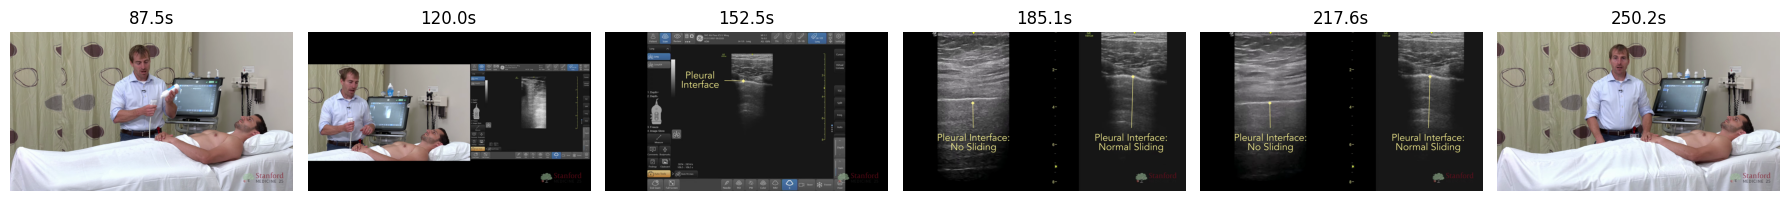

In [5]:
# Show N evenly-spaced frames from the chosen clip
import cv2, numpy as np, matplotlib.pyplot as plt

N_FRAMES = 6
cap = cv2.VideoCapture(str(VIDEO_PATH))
times = np.linspace(float(clip["start"]), float(clip["end"]), N_FRAMES)

fig, axes = plt.subplots(1, N_FRAMES, figsize=(3 * N_FRAMES, 3))
for ax, t in zip(axes, times):
    cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000.0)
    ok, frame = cap.read()
    if not ok:
        ax.set_title(f"{t:.1f}s (fail)")
        ax.axis("off")
        continue
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{t:.1f}s")
    ax.axis("off")
cap.release()
plt.tight_layout()
plt.show()


In [6]:
asr_text = slice_asr_text_for_clip(TRANSCRIPT_JSON, float(clip["start"]), float(clip["end"]))
print(f"ASR text length: {len(asr_text)} chars")
print(asr_text[:400] + ("..." if len(asr_text) > 400 else ""))


ASR text length: 2979 chars
But we'll be able to see the best today with linear probe, so I like to show you with this. When we position our patient, we'll usually have the patient lying flat. We can have the bed up maybe a little bit like here we have a pillow under his head, but it's really important because air is going to rise and we want to put the probe where the air would go. If we have the patient sitting straight up...


## 3. Run the temporal QA pipeline

Single-stage: one MLLM call on the full clip → temporal QA pairs.
Expect ~30s–2 min wall-time. You can change `MODEL` to test different models.

In [8]:
OUT_PATH = REPO_ROOT / "results" / "qa" / f"{VIDEO_ID}_temporal_qa_clip{CLIP_IDX}.json"
print("Will save to:", OUT_PATH)

client = build_openrouter_client()
MODEL = "google/gemini-2.5-pro"

result = generate_temporal_qa_for_clip(
    video_path=str(VIDEO_PATH),
    clip=clip,
    transcript_path=str(TRANSCRIPT_JSON) if TRANSCRIPT_JSON.exists() else None,
    max_qa=10,
    model=MODEL,
    output_path=str(OUT_PATH),
    client=client,
    verbose=True,
)

print()
print("Top-level keys:", list(result.keys()))
print("Num temporal QA:", len(result["temporal_qa"]))
print("Elapsed:", result["elapsed_sec"], "s")

Will save to: /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/results/qa/8V649L5Q368_temporal_qa_clip1.json
[temporal-qa] clip 1: 87.45s -> 250.17s (162.7s)
[temporal-qa] ASR provided: True (2979 chars)
[temporal-qa] QA generated: 6  (raw 6, dropped 0)  (82.1s)
[temporal-qa] saved -> /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/results/qa/8V649L5Q368_temporal_qa_clip1.json

Top-level keys: ['video_id', 'clip_idx', 'clip_start', 'clip_end', 'clip_topic', 'model', 'asr_used_at_generation', 'temporal_qa', 'stage_meta', 'elapsed_sec']
Num temporal QA: 6
Elapsed: 82.09 s


## 4. Inspect temporal QA

In [9]:
from collections import Counter

types = Counter(qa["qa_type"] for qa in result["temporal_qa"])
print("QA type distribution:")
for t, c in types.most_common():
    print(f"  {t:35s} x {c}")
print()

for qa in result["temporal_qa"]:
    print(f"== {qa['qa_type']}  (query_time={qa['query_time']:.1f}s)")
    print(f"   input_video : [{qa['input_video_start']:.1f}s, {qa['input_video_end']:.1f}s]  (seen-only)")
    print(f"   Q: {qa['question']}")
    print(f"   A: {qa['answer']}")
    if qa.get("evidence"):
        print(f"   evidence: {qa['evidence']}")
    print()

QA type distribution:
  given_when_ask_what                 x 2
  next_action_guidance                x 2
  visible_anatomy                     x 1
  given_what_ask_when                 x 1

== given_when_ask_what  (query_time=115.8s)
   input_video : [87.5s, 115.8s]  (seen-only)
   Q: Why is the patient positioned lying flat for this ultrasound examination?
   A: The patient is positioned lying flat because air from a potential pneumothorax will rise to the most anterior part of the chest. Scanning this highest point increases the likelihood of detecting it.
   evidence: The narrator explains that air is going to rise and the probe should be placed where the air would go.

== visible_anatomy  (query_time=128.5s)
   input_video : [87.5s, 128.5s]  (seen-only)
   Q: What structures are visible in the ultrasound image right now?
   A: The ultrasound shows the chest wall, including two hyperechoic ribs with posterior acoustic shadowing, and the bright, horizontal pleural line located betwe

## 5. (Optional) Inspect raw response

In [ ]:
sm = result.get("stage_meta", {})
print("model        =", sm.get("model"))
print("raw_qa_count =", sm.get("raw_qa_count"))
print("qa_kept      =", sm.get("qa_kept"))
print("qa_dropped   =", sm.get("qa_dropped"))
print("parse_error  =", sm.get("parse_error"))
print()
print("--- raw_response (first 2000 chars) ---")
print(sm.get("raw_response", "")[:2000])


## 6. (Optional) Re-run with ASR disabled

`Seen ASR` is optional. Passing `transcript_path=None` makes the generator use only the video.

In [10]:
result_no_asr = generate_temporal_qa_for_clip(
    video_path=str(VIDEO_PATH),
    clip=clip,
    transcript_path=None,
    max_qa=6,
    model=MODEL,
    output_path=None,
    client=client,
    verbose=True,
)

print()
print("Num temporal QA (no ASR):", len(result_no_asr["temporal_qa"]))
for qa in result_no_asr["temporal_qa"][:4]:
    print(f"- [{qa['qa_type']}] Q: {qa['question']}")
    print(f"    A: {qa['answer']}")


[temporal-qa] clip 1: 87.45s -> 250.17s (162.7s)
[temporal-qa] ASR provided: False (0 chars)
      retry 1/5 (transient) after 8.0s (prev: Expecting value: line 187 column 1 (char 1023))
[temporal-qa] QA generated: 6  (raw 6, dropped 0)  (227.3s)

Num temporal QA (no ASR): 6
- [visible_anatomy] Q: What anatomical structures are visible in the ultrasound image at this time?
    A: The image displays a cross-section of the chest wall. Two hyperechoic ribs are seen with posterior acoustic shadowing. Between and slightly below them is the bright, hyperechoic pleural line, which is the interface between the visceral and parietal pleura.
- [given_when_ask_what] Q: The sonographer mentions seeing 'ants on a log'. What does this observation signify in a lung ultrasound?
    A: The 'ants on a log' sign is a visual description of normal lung sliding. It refers to the shimmering or sliding movement along the pleural line, which indicates that the visceral and parietal pleura are in apposition and